# Multivariate Analysis and Predictive Modeling of Digital Health Readiness in India

### DS3005 – Computational Algorithms in Data Science

**Team Members: Lakshya Gupta, Sarthak Goel, Krissh Modi**

In [35]:
"""
================================================================================
  Multivariate Analysis and Predictive Modeling of Digital Health Readiness
  in India — DS3005 Computational Algorithms in Data Science
  Authors : Lakshya Gupta, Sarthak Goel, Krissh Modi
  Date    : April 2026
================================================================================

Pipeline
────────
  STEP 1  │ Data Loading & Preprocessing
  STEP 2  │ Feature Engineering — Digital Readiness Score (DRS)
  STEP 3  │ Full-Predictor PCA
  STEP 4  │ K-Means Clustering
  STEP 5  │ Logistic Regression
  STEP 6  │ Random Forest
  STEP 7  │ Gradient Boosting
  STEP 8  │ Model Validation & Comparison
  STEP 9  │ Visualizations
================================================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 10})

SEED = 42
np.random.seed(SEED)

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING & PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 1 — Data Loading & Preprocessing")
print("=" * 72)

# Dataset: Citizen Survey Dataset, India (Kalita et al., 2026)
# Source : https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/M1DFBO
DATA_PATH = "./dataverse_files/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025 (1)/FINAL DATA-CITIZEN_SURVEY_ALL_DATA-FINAL_SKS_09.05.2025.dta"
df_raw = pd.read_stata(DATA_PATH)

print(f"  Raw dataset shape : {df_raw.shape}")

# ── Inspect actual column values before encoding ──────────────────────────────
INSPECT_COLS = ["c17_f", "c16_g", "c17_a", "c17_b", "c17_c",
                "c17_d", "c17_e", "c18_a", "a2c", "residence", "rec_a2d"]
print("\n  Unique values per key column (encoding reference):")
for col in INSPECT_COLS:
    if col in df_raw.columns:
        vals = df_raw[col].dropna().unique()[:8]
        print(f"    {col:<12}: {list(vals)}")
print()

# ── Robust mappers for Stata-labeled categorical columns ──────────────────────
def _clean_labels(series):
    return series.astype(str).str.strip().str.lower()


def map_binary_labels(series, positive_labels, negative_labels):
    """Map string-labeled categories to {1, 0, NaN}."""
    cleaned = _clean_labels(series)
    pos = {x.lower() for x in positive_labels}
    neg = {x.lower() for x in negative_labels}
    out = pd.Series(np.nan, index=series.index, dtype=float)
    out.loc[cleaned.isin(pos)] = 1.0
    out.loc[cleaned.isin(neg)] = 0.0
    return out


def map_ordinal_labels(series, mapping):
    """Map string-labeled categories to ordered numeric scores."""
    cleaned = _clean_labels(series)
    mapping = {k.lower(): float(v) for k, v in mapping.items()}
    return cleaned.map(mapping).astype(float)


# ── Variable mapping (from Variable Directory) ────────────────────────────────
#
# TARGET   : c17_f  — "Video-call consultations"
#            Recode as binary: {Great Extent, Somewhat}=1, Very Little=0,
#            {DK, DNA}=missing (dropped from target).
#
# PREDICTORS:
#   a2b_age    — Age in completed years                        [Continuous]
#   a2g_food   — Household food expenditure (income proxy)     [Continuous]
#   rec_a2d    — Grouped education level recode                [Ordinal]
#   a2c        — Gender of respondent (Male/Female)            [Binary]
#   residence  — Rural / Urban (NSSO classification)           [Binary]
#   c16_g      — Internet as source of health information      [Binary]
#   c17_a      — General health info usage intensity           [Binary recode]
#   c17_b      — E-pharmacy usage intensity                    [Binary recode]
#   c17_c      — Uses internet to find doctors / facilities    [Binary recode]
#   c17_d      — Uses internet to access medical records       [Binary recode]
#   c17_e      — Uses internet for help with treatment         [Binary recode]
#   c18_a      — Health card likely important for health care  [Binary]

df = df_raw.copy()

# ── Encode TARGET ─────────────────────────────────────────────────────────────
TARGET_COL = "telemedicine_usage"
df[TARGET_COL] = map_binary_labels(
    df["c17_f"],
    positive_labels={"Great Extent", "Somewhat"},
    negative_labels={"Very Little"},
)

# ── Encode binary predictors ──────────────────────────────────────────────────
# c16_g uses Yes(Spontaneous)/Yes(Prompted)/No/DNA coding
df["c16_g"] = map_binary_labels(
    df["c16_g"],
    positive_labels={"Yes(Spontaneous)", "Yes(Prompted)"},
    negative_labels={"No"},
)

# c17_a..e use Great Extent/Somewhat/Very Little/DK/DNA coding
for col in ["c17_a", "c17_b", "c17_c", "c17_d", "c17_e"]:
    df[col] = map_binary_labels(
        df[col],
        positive_labels={"Great Extent", "Somewhat"},
        negative_labels={"Very Little"},
    )

# ── Encode gender (Female = 1, Male = 0) ─────────────────────────────────────
df["gender"] = map_binary_labels(
    df["a2c"],
    positive_labels={"Female"},
    negative_labels={"Male"},
)

# ── Encode residence (Rural = 1, Urban = 0) ──────────────────────────────────
df["rural"] = map_binary_labels(
    df["residence"],
    positive_labels={"Rural"},
    negative_labels={"Urban"},
)

# ── Encode c18_a (Yes = 1, No = 0) ────────────────────────────────────────────
df["c18_a"] = map_binary_labels(
    df["c18_a"],
    positive_labels={"Yes"},
    negative_labels={"No"},
)

# ── Encode education as ordinal integer ───────────────────────────────────────
EDU_ORDER = {
    "primary": 1,
    "middle": 2,
    "secondary": 3,
    "higher-secondary+": 4,
}
df["education"] = map_ordinal_labels(df["rec_a2d"], EDU_ORDER)

# ── Verify encoding produced sensible results ─────────────────────────────────
print("  Encoded value counts for target and key predictors:")
for col in [TARGET_COL, "gender", "rural", "c16_g", "c17_a", "c18_a", "education"]:
    vc = df[col].value_counts(dropna=False).to_dict()
    print(f"    {col:<22}: {vc}")
print()

# ── Final predictor column names ──────────────────────────────────────────────
PREDICTOR_COLS = [
    "a2b_age",    # Age
    "a2g_food",   # Household food expenditure (income proxy)
    "education",  # Ordinal education level
    "gender",     # Female=1, Male=0
    "rural",      # Rural=1, Urban=0
    "c16_g",      # Internet as health info source (internet access proxy)
    "c17_a",      # Uses internet for general health information
    "c17_b",      # Uses internet for e-pharmacies
    "c17_c",      # Uses internet to find doctors/facilities
    "c17_d",      # Uses internet for medical records
    "c17_e",      # Uses internet for treatment help
    "c18_a",      # Health card importance
]

# ── Subset and drop rows with missing target ──────────────────────────────────
df_work = df[PREDICTOR_COLS + [TARGET_COL]].copy()
df_work = df_work[df_work[TARGET_COL].notna()].reset_index(drop=True)

if len(df_work) == 0:
    raise ValueError(
        "0 rows remain after target recoding. Check the mapping for c17_f values."
    )

if df_work[TARGET_COL].nunique() < 2:
    raise ValueError(
        "Target has only one class after recoding. Adjust c17_f mapping to ensure a valid binary outcome."
    )

print(f"  Rows with valid target (c17_f): {len(df_work):,}")
print(f"  Target distribution: {df_work[TARGET_COL].value_counts().to_dict()}")
print(f"  Y=1 (telemedicine used): {df_work[TARGET_COL].mean()*100:.1f}%")

# ── Missing value imputation ──────────────────────────────────────────────────
continuous_vars = ["a2b_age", "a2g_food"]
ordinal_binary_vars = [c for c in PREDICTOR_COLS if c not in continuous_vars]

df_work[continuous_vars] = (SimpleImputer(strategy="median")
                            .fit_transform(df_work[continuous_vars]))
df_work[ordinal_binary_vars] = (SimpleImputer(strategy="most_frequent")
                                .fit_transform(df_work[ordinal_binary_vars]))

print(f"  Missing values after imputation: {df_work.isnull().sum().sum()}")

# ── Z-score standardisation — required before PCA and K-Means ─────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work[PREDICTOR_COLS])
df_scaled = pd.DataFrame(X_scaled, columns=PREDICTOR_COLS, index=df_work.index)

print(f"  Predictors standardised: {df_scaled.shape}\n")

y = df_work[TARGET_COL].values.astype(int)
N = len(df_work)
df = df_work

STEP 1 — Data Loading & Preprocessing
  Raw dataset shape : (50217, 232)

  Unique values per key column (encoding reference):
    c17_f       : ['Great Extent', 'Very Little', 'DK', 'DNA', 'Somewhat']
    c16_g       : ['Yes(Spontaneous)', 'DNA', 'No', 'Yes(Prompted)']
    c17_a       : ['Great Extent', 'Very Little', 'DK', 'DNA', 'Somewhat']
    c17_b       : ['Great Extent', 'Very Little', 'Somewhat', 'DK', 'DNA']
    c17_c       : ['Great Extent', 'DNA', 'Very Little', 'Somewhat', 'DK']
    c17_d       : ['Great Extent', 'DNA', 'Very Little', 'Somewhat', 'DK']
    c17_e       : ['Somewhat', 'DNA', 'Very Little', 'Great Extent', 'DK']
    c18_a       : ['Yes', 'No', 'CNS', 'DNA']
    a2c         : ['Female', 'Male', 'DNA', 'Others']
    residence   : ['Urban', 'Rural']
    rec_a2d     : ['Higher-Secondary+', 'Primary', 'Secondary', 'Middle', 'DNA']

  Encoded value counts for target and key predictors:
    telemedicine_usage    : {0.0: 20044, nan: 19588, 1.0: 10585}
    gender      

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — FEATURE ENGINEERING: Digital Readiness Score (DRS)
# ══════════════════════════════════════════════════════════════════════════════
# DRS is extracted as PC1 of a PCA over six digital-readiness indicators:
#   c16_g  — internet as health information source (internet access proxy)
#   c17_a  — uses internet for general health information
#   c17_b  — uses internet for e-pharmacies / medicines
#   c17_c  — uses internet to find doctors and facilities
#   c17_d  — uses internet to access medical records
#   c17_e  — uses internet for help with treatment
#
# DRS_i = v₁ᵀ xᵢ  where v₁ is the eigenvector of the largest eigenvalue of Σ
#
# If PC1 explains < 60% of variance, a variance-weighted composite is used instead.

print("=" * 72)
print("STEP 2 — Feature Engineering: Digital Readiness Score (DRS)")
print("=" * 72)

DRS_COLS = ["c16_g", "c17_a", "c17_b", "c17_c", "c17_d", "c17_e"]
X_drs = df_scaled[DRS_COLS].values

# Guard against degenerate input (all DRS features constant).
if np.all(np.std(X_drs, axis=0) < 1e-12):
    raise ValueError(
        "DRS features are constant after preprocessing; cannot compute PCA-based DRS."
    )

pca_drs = PCA(n_components=len(DRS_COLS), random_state=SEED)
pca_drs.fit(X_drs)

evr = pca_drs.explained_variance_ratio_
if not np.isfinite(evr).all():
    raise ValueError(
        "DRS PCA produced non-finite explained variance ratios. Check Step 1 recoding and imputation."
    )

pc1_variance = evr[0]

print(f"  Variance explained per PC: {np.round(evr * 100, 1)} %")
print(f"  PC1 variance: {pc1_variance * 100:.1f}%")

if pc1_variance >= 0.60:
    DRS = pca_drs.transform(X_drs)[:, 0]
    print("  PC1 >= 60% — using PC1 as DRS")
else:
    weights = evr / evr.sum()
    DRS = pca_drs.transform(X_drs) @ weights
    print("  PC1 < 60% — using variance-weighted composite as DRS")

print("\n  PC1 Loadings:")
for var, load in zip(DRS_COLS, pca_drs.components_[0]):
    print(f"    {var:<22} : {load:+.4f}")

df["DRS"] = DRS
df_scaled["DRS"] = DRS
print(f"\n  DRS added. Mean = {DRS.mean():.3f}, Std = {DRS.std():.3f}\n")

STEP 2 — Feature Engineering: Digital Readiness Score (DRS)
  Variance explained per PC: [54.5 13.5 12.1  7.6  6.9  5.3] %
  PC1 variance: 54.5%
  PC1 < 60% — using variance-weighted composite as DRS

  PC1 Loadings:
    c16_g                  : +0.3269
    c17_a                  : +0.4388
    c17_b                  : +0.4399
    c17_c                  : +0.4643
    c17_d                  : +0.4598
    c17_e                  : +0.2829

  DRS added. Mean = -0.000, Std = 1.001



In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — FULL-PREDICTOR PCA
# ══════════════════════════════════════════════════════════════════════════════
# Applied to all 12 predictors to reduce the feature space before clustering.
# Retains the top d components that together explain >= 80% cumulative variance.
# The projected matrix Z = X Vd serves as input to K-Means.

print("=" * 72)
print("STEP 3 — Full-Predictor PCA")
print("=" * 72)

X_full   = df_scaled[PREDICTOR_COLS].values
pca_full = PCA(n_components=None, random_state=SEED)
pca_full.fit(X_full)

cumvar          = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = int(np.argmax(cumvar >= 0.80)) + 1

print("  Cumulative variance by component:")
for i, (ev, cv) in enumerate(zip(pca_full.explained_variance_ratio_, cumvar)):
    marker = "  <- 80% threshold" if i + 1 == n_components_80 else ""
    print(f"    PC{i+1}: {ev*100:5.1f}%  (cumulative {cv*100:5.1f}%){marker}")

pca_final = PCA(n_components=n_components_80, random_state=SEED)
Z = pca_final.fit_transform(X_full)

print(f"\n  Components retained: d = {n_components_80}")
print(f"  Projected matrix Z : {Z.shape}\n")

STEP 3 — Full-Predictor PCA
  Cumulative variance by component:
    PC1:  28.9%  (cumulative  28.9%)
    PC2:  11.3%  (cumulative  40.3%)
    PC3:   9.5%  (cumulative  49.8%)
    PC4:   8.7%  (cumulative  58.5%)
    PC5:   8.3%  (cumulative  66.8%)
    PC6:   6.8%  (cumulative  73.6%)
    PC7:   6.4%  (cumulative  80.0%)
    PC8:   5.8%  (cumulative  85.8%)  <- 80% threshold
    PC9:   4.3%  (cumulative  90.2%)
    PC10:   3.8%  (cumulative  93.9%)
    PC11:   3.4%  (cumulative  97.4%)
    PC12:   2.6%  (cumulative 100.0%)

  Components retained: d = 8
  Projected matrix Z : (30629, 8)



In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — K-MEANS CLUSTERING
# ══════════════════════════════════════════════════════════════════════════════
# Minimises WCSS = Σ_k Σ_{i∈Ck} ‖zᵢ − μₖ‖²
# Optimal K selected jointly by the elbow method and maximum silhouette score.
# Silhouette is computed on a 5,000-point subsample for efficiency.

print("=" * 72)
print("STEP 4 — K-Means Clustering")
print("=" * 72)

K_RANGE = range(2, 8)
wcss, sil_scores = [], []

sil_idx  = np.random.choice(N, min(5000, N), replace=False)
Z_sample = Z[sil_idx]

print("  Evaluating K values...", end="")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10,
                max_iter=300, random_state=SEED)
    km.fit(Z)
    wcss.append(km.inertia_)
    labels_sample = km.labels_[sil_idx]
    sil = (silhouette_score(Z_sample, labels_sample, random_state=SEED)
           if len(np.unique(labels_sample)) > 1 else -1)
    sil_scores.append(sil)
    print(".", end="", flush=True)
print()

best_k_sil = K_RANGE.start + int(np.argmax(sil_scores))
print(f"\n  K   WCSS              Silhouette")
for k, w, s in zip(K_RANGE, wcss, sil_scores):
    marker = "  <- optimal" if k == best_k_sil else ""
    print(f"  K={k}  {w:>12,.0f}    {s:.4f}{marker}")

K_OPT          = best_k_sil
km_final       = KMeans(n_clusters=K_OPT, init="k-means++", n_init=20,
                        max_iter=500, random_state=SEED)
cluster_labels = km_final.fit_predict(Z)
df["cluster"]  = cluster_labels

print(f"\n  Optimal K = {K_OPT}")
for k, cnt in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f"  Cluster {k}: {cnt:,}  ({cnt/N*100:.1f}%)")

cluster_profile = (df[PREDICTOR_COLS + [TARGET_COL, "cluster"]]
                   .groupby("cluster").mean().round(3))
print(f"\n  Cluster Profiles:\n{cluster_profile}\n")

STEP 4 — K-Means Clustering
  Evaluating K values.........

  K   WCSS              Silhouette
  K=2       230,314    0.2786
  K=3       203,710    0.2969  <- optimal
  K=4       179,527    0.2132
  K=5       165,573    0.2072
  K=6       155,085    0.1900
  K=7       147,190    0.1864

  Optimal K = 3
  Cluster 0: 2,217  (7.2%)
  Cluster 1: 19,686  (64.3%)
  Cluster 2: 8,726  (28.5%)

  Cluster Profiles:
         a2b_age  a2g_food  education  gender  rural  c16_g  c17_a  c17_b  \
cluster                                                                     
0         37.444  6294.406      2.518   0.424  0.661  0.615  0.740  0.606   
1         36.476  6086.823      2.861   0.396  0.664  0.845  0.957  0.871   
2         40.040  5912.854      2.061   0.498  0.756  0.374  0.271  0.103   

         c17_c  c17_d  c17_e  c18_a  telemedicine_usage  
cluster                                                  
0        0.664  0.665  0.322    0.0               0.377  
1        0.924  0.912  0.457   

In [40]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 5 — LOGISTIC REGRESSION
# ══════════════════════════════════════════════════════════════════════════════
# P(Y=1 | X) = 1 / (1 + exp(−(β₀ + βᵀX)))
#
# Interaction terms (as specified in §5.5 of the proposal):
#   Gender × Rural    — effect of gender is expected to differ by residential type
#   Income × Internet — effect of internet access is expected to differ by income level
#                       (a2g_food is the income proxy; c16_g is the internet access proxy)
#
# Cluster membership is added as dummy-encoded features.
# Coefficients are exponentiated to yield interpretable odds ratios e^βⱼ.

print("=" * 72)
print("STEP 5 — Logistic Regression")
print("=" * 72)

df_model = df_scaled.copy()

# Interaction: Gender × Rural (both raw binary 0/1 from original encoding)
df_model["gender_x_rural"]    = df["gender"]  * df["rural"]

# Interaction: Income × Internet (standardised food expenditure × binary c16_g)
df_model["income_x_internet"] = df_scaled["a2g_food"] * df["c16_g"]

cluster_dummies = pd.get_dummies(df["cluster"], prefix="cluster", drop_first=True)
df_model = pd.concat([df_model.reset_index(drop=True),
                      cluster_dummies.reset_index(drop=True)], axis=1)

FEATURE_COLS = (
    PREDICTOR_COLS
    + ["DRS", "gender_x_rural", "income_x_internet"]
    + list(cluster_dummies.columns)
)

X = df_model[FEATURE_COLS].values
print(f"  Feature matrix: {X.shape}  (p = {X.shape[1]})")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"  Y=1 — Train: {y_train.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%\n")

lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=500,
                        class_weight="balanced", random_state=SEED)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

odds_ratios = np.exp(lr.coef_[0])
print("  Odds Ratios (sorted by effect magnitude):")
for feat, OR in sorted(zip(FEATURE_COLS, odds_ratios), key=lambda x: -abs(x[1] - 1)):
    print(f"    {feat:<30}: {OR:.4f}  {'↑' if OR > 1 else '↓'}")
print()

STEP 5 — Logistic Regression
  Feature matrix: (30629, 17)  (p = 17)
  Train: 24,503  |  Test: 6,126
  Y=1 — Train: 34.6%  Test: 34.6%

  Odds Ratios (sorted by effect magnitude):
    c17_e                         : 4.2934  ↑
    DRS                           : 1.5654  ↑
    cluster_2                     : 0.7082  ↓
    income_x_internet             : 1.2269  ↑
    c17_d                         : 1.1969  ↑
    education                     : 1.1638  ↑
    rural                         : 1.1345  ↑
    c17_b                         : 1.1282  ↑
    c18_a                         : 0.8781  ↓
    gender                        : 1.1030  ↑
    gender_x_rural                : 0.9059  ↓
    c16_g                         : 1.0546  ↑
    c17_c                         : 1.0500  ↑
    c17_a                         : 1.0246  ↑
    a2g_food                      : 1.0137  ↑
    cluster_1                     : 1.0069  ↑
    a2b_age                       : 1.0048  ↑



In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — RANDOM FOREST
# ══════════════════════════════════════════════════════════════════════════════
# Ŷ = mode(T₁(X), …, T_B(X))
# B = 200 trees, each split considers m = √p random features.
# OOB score provides an unbiased generalisation estimate without a held-out set.

print("=" * 72)
print("STEP 6 — Random Forest")
print("=" * 72)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, max_features="sqrt",
    class_weight="balanced", oob_score=True,
    n_jobs=-1, random_state=SEED
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"  OOB accuracy: {rf.oob_score_:.4f}")

importance_df = (pd.DataFrame({"feature": FEATURE_COLS,
                                "importance": rf.feature_importances_})
                 .sort_values("importance", ascending=False))
print("\n  Top-10 Feature Importances:")
print(importance_df.head(10).to_string(index=False))
print()

STEP 6 — Random Forest
  OOB accuracy: 0.8769

  Top-10 Feature Importances:
          feature  importance
            c17_e    0.409517
              DRS    0.282499
        cluster_2    0.077505
        education    0.071086
            c17_d    0.033341
        cluster_1    0.025813
            c17_c    0.023436
income_x_internet    0.014134
          a2b_age    0.012643
         a2g_food    0.011885



In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 7 — GRADIENT BOOSTING
# ══════════════════════════════════════════════════════════════════════════════
# Third comparator (§5.7). Trees are built sequentially, each correcting the
# residuals of the prior ensemble. subsample=0.8 adds stochasticity to reduce
# variance (stochastic gradient boosting).

print("=" * 72)
print("STEP 7 — Gradient Boosting")
print("=" * 72)

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=4, subsample=0.8, random_state=SEED
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("  Gradient Boosting fitted.\n")

STEP 7 — Gradient Boosting
  Gradient Boosting fitted.



In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 8 — MODEL VALIDATION & COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
# Three-layer evaluation strategy (§5.7):
#   Holdout metrics : Accuracy, Precision, Recall, F1, ROC-AUC on 20% test set
#   5-fold CV AUC   : on training set, stratified
#   Bootstrap CIs   : B=1000 resamples of the test set → 95% CI on ROC-AUC
#
# Primary metric is ROC-AUC (robust to class imbalance).

print("=" * 72)
print("STEP 8 — Model Validation & Comparison")
print("=" * 72)


def compute_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob), 4),
    }


def bootstrap_auc_ci(y_true, y_prob, B=1000, seed=SEED):
    """95% bootstrap confidence interval for ROC-AUC."""
    rng  = np.random.RandomState(seed)
    aucs = []
    for _ in range(B):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, [2.5, 97.5])


results_df = pd.DataFrame([
    compute_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression"),
    compute_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"),
    compute_metrics(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting"),
]).set_index("Model")

print("\n  Holdout Test Set Metrics:")
print(results_df.to_string())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print("\n  5-Fold CV ROC-AUC (training set):")
for model, name in [(lr, "Logistic Regression"),
                    (rf, "Random Forest"),
                    (gb, "Gradient Boosting")]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"    {name:<25}: {scores.mean():.4f} ± {scores.std():.4f}"
          f"  (folds: {np.round(scores, 3)})")

print("\n  Bootstrap 95% CIs for ROC-AUC (B=1000):")
for y_prob, name in [(y_prob_lr, "Logistic Regression"),
                     (y_prob_rf, "Random Forest"),
                     (y_prob_gb, "Gradient Boosting")]:
    lo, hi = bootstrap_auc_ci(y_test, y_prob)
    auc    = roc_auc_score(y_test, y_prob)
    print(f"    {name:<25}: AUC = {auc:.4f}  [95% CI: {lo:.4f} – {hi:.4f}]")

print()

STEP 8 — Model Validation & Comparison

  Holdout Test Set Metrics:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8779     0.8334  0.8082  0.8206   0.9114
Random Forest          0.8800     0.8348  0.8139  0.8242   0.9306
Gradient Boosting      0.8810     0.8491  0.7974  0.8224   0.9309

  5-Fold CV ROC-AUC (training set):
    Logistic Regression      : 0.9052 ± 0.0035  (folds: [0.908 0.899 0.909 0.904 0.905])
    Random Forest            : 0.9245 ± 0.0018  (folds: [0.925 0.922 0.926 0.923 0.927])
    Gradient Boosting        : 0.9253 ± 0.0014  (folds: [0.925 0.923 0.927 0.925 0.927])

  Bootstrap 95% CIs for ROC-AUC (B=1000):
    Logistic Regression      : AUC = 0.9114  [95% CI: 0.9033 – 0.9192]
    Random Forest            : AUC = 0.9306  [95% CI: 0.9236 – 0.9369]
    Gradient Boosting        : AUC = 0.9309  [95% CI: 0.9240 – 0.9372]



STEP 9 — Generating Visualizations


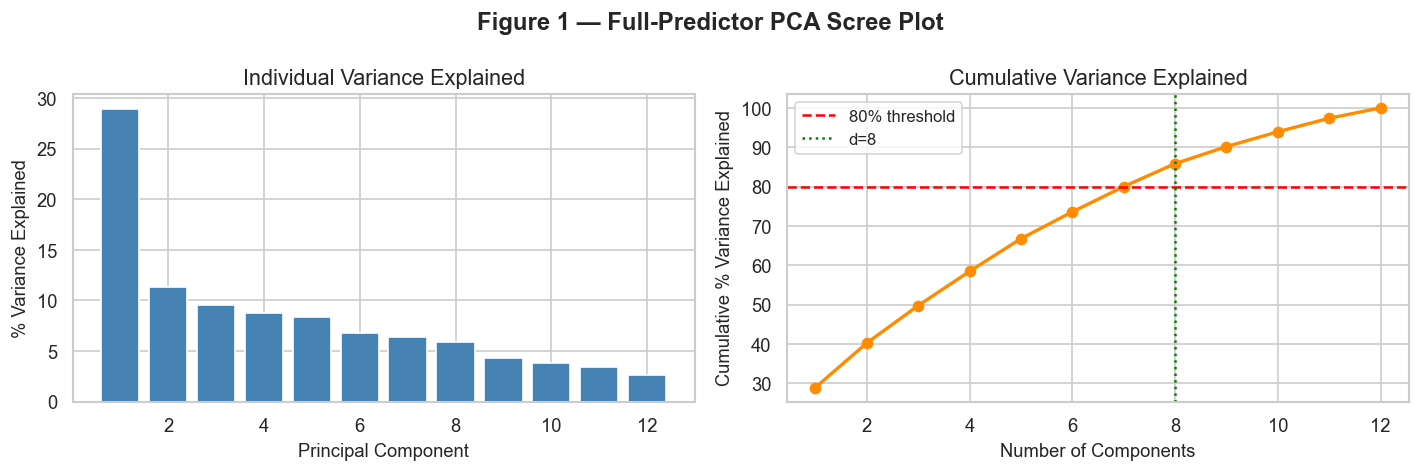

  ✓ Figure 1 displayed


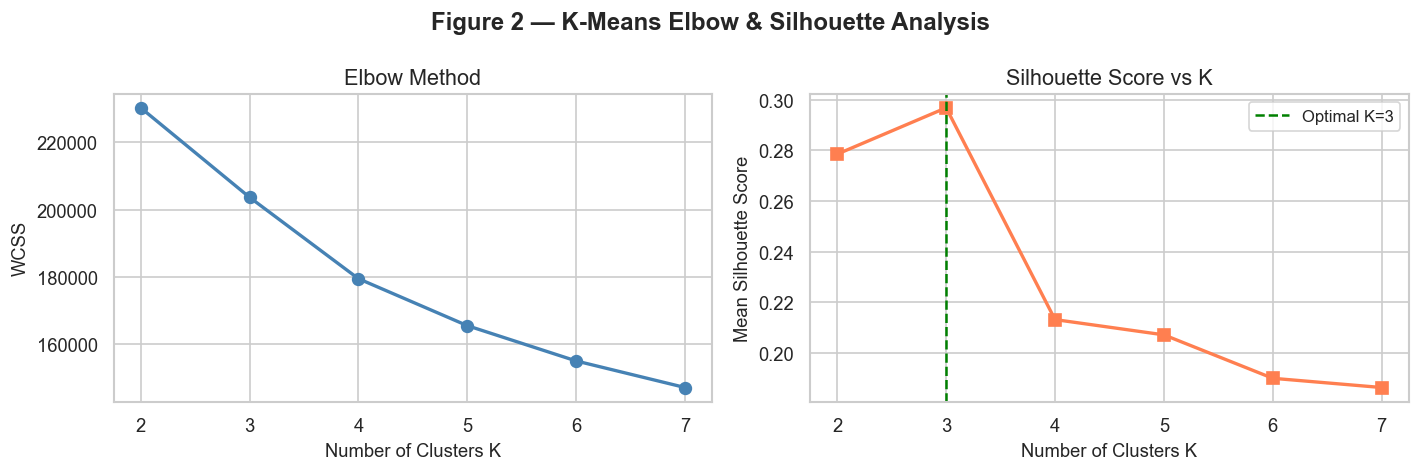

  ✓ Figure 2 displayed


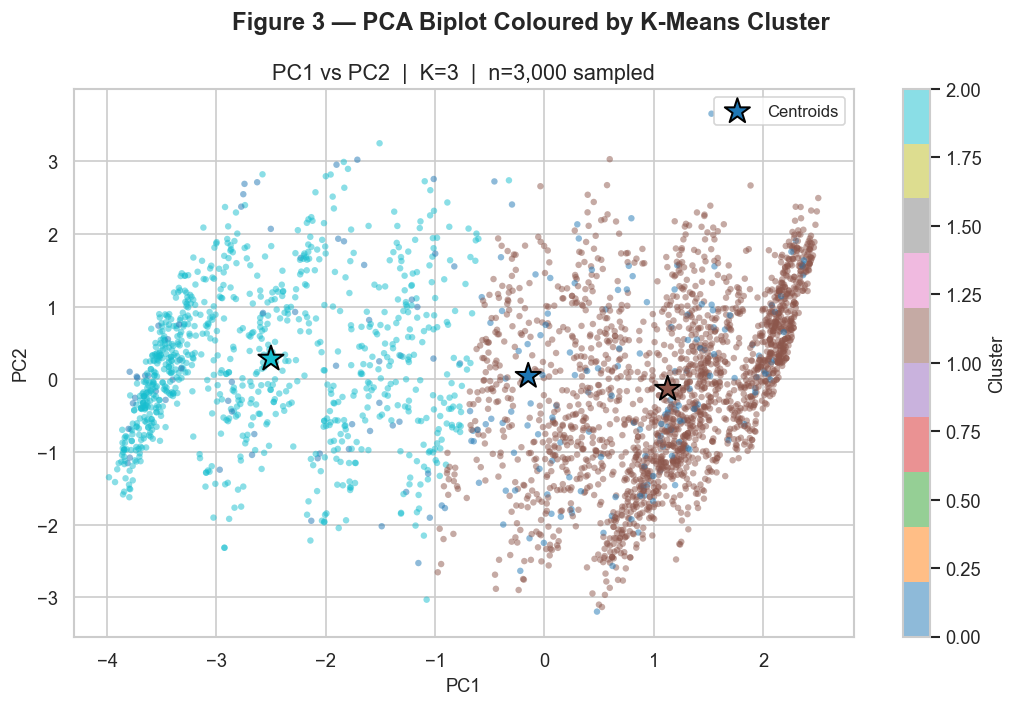

  ✓ Figure 3 displayed


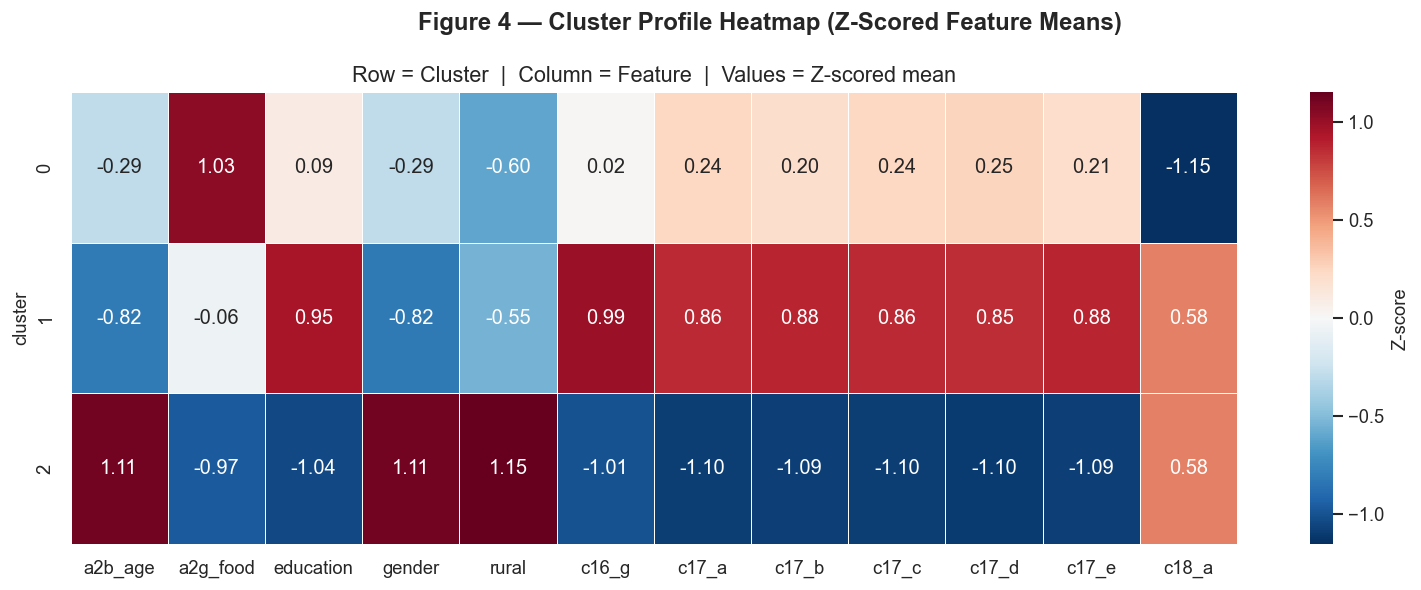

  ✓ Figure 4 displayed


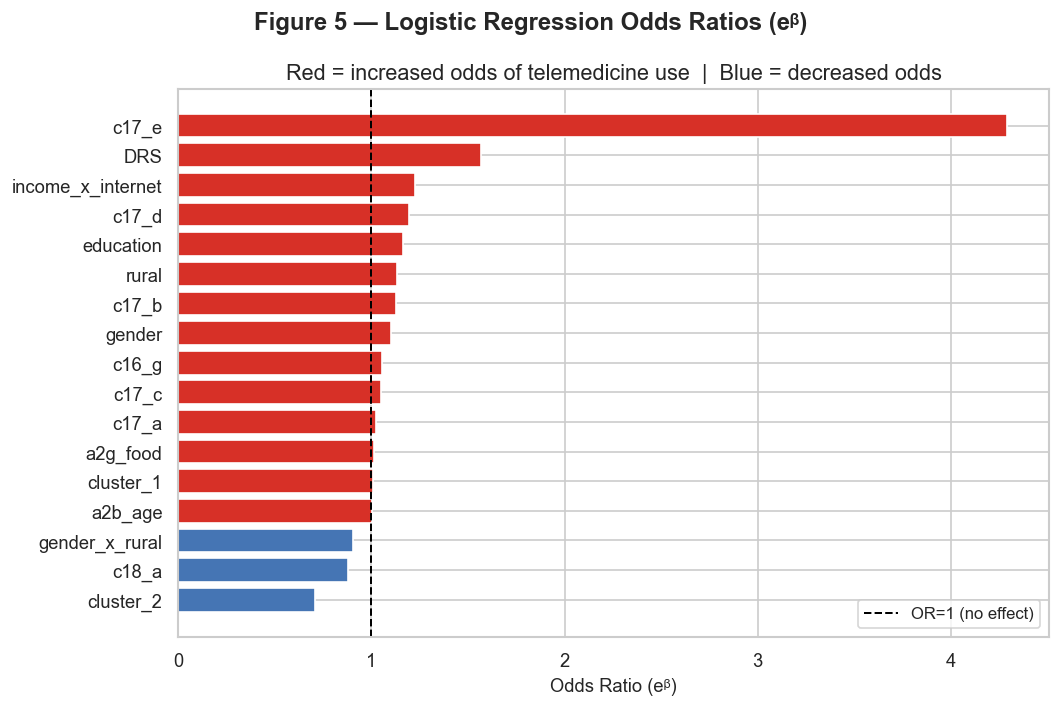

  ✓ Figure 5 displayed


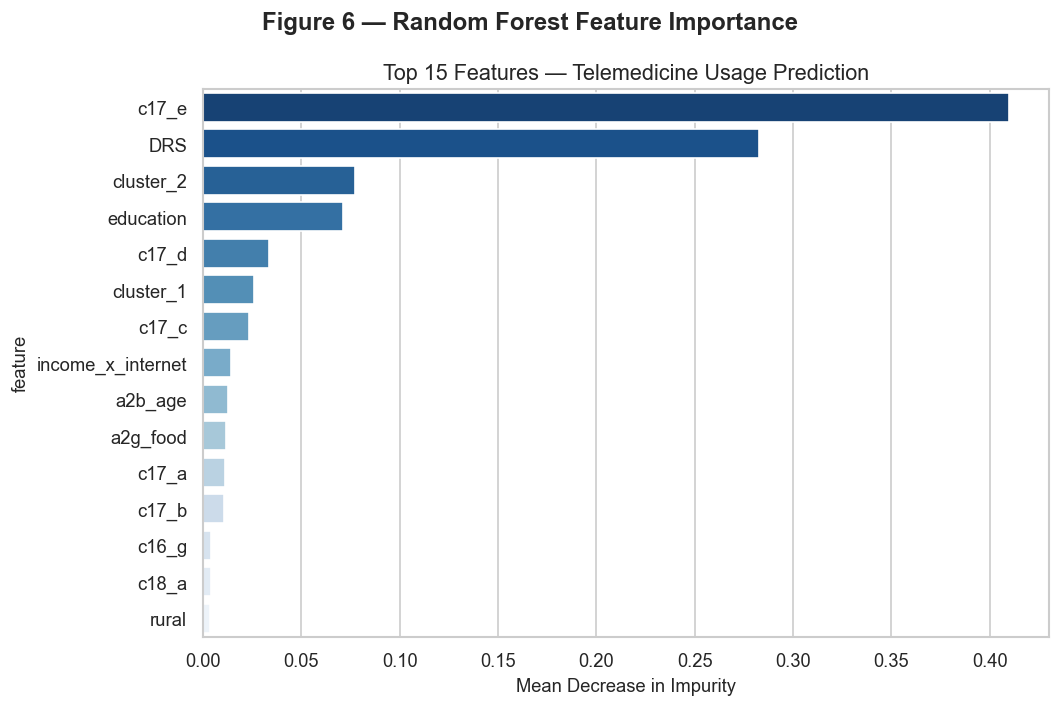

  ✓ Figure 6 displayed


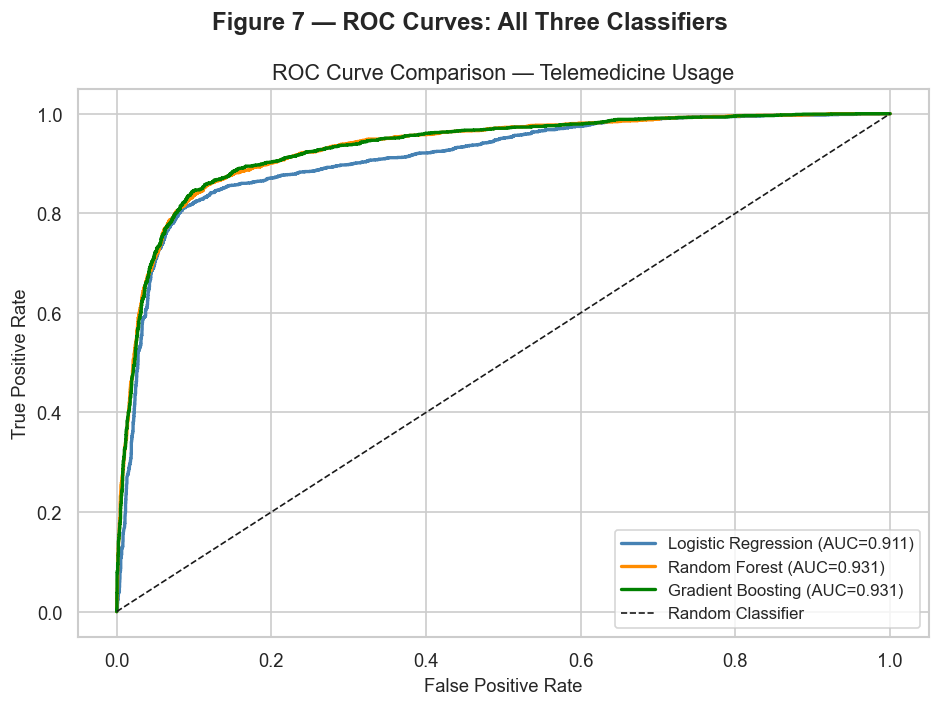

  ✓ Figure 7 displayed


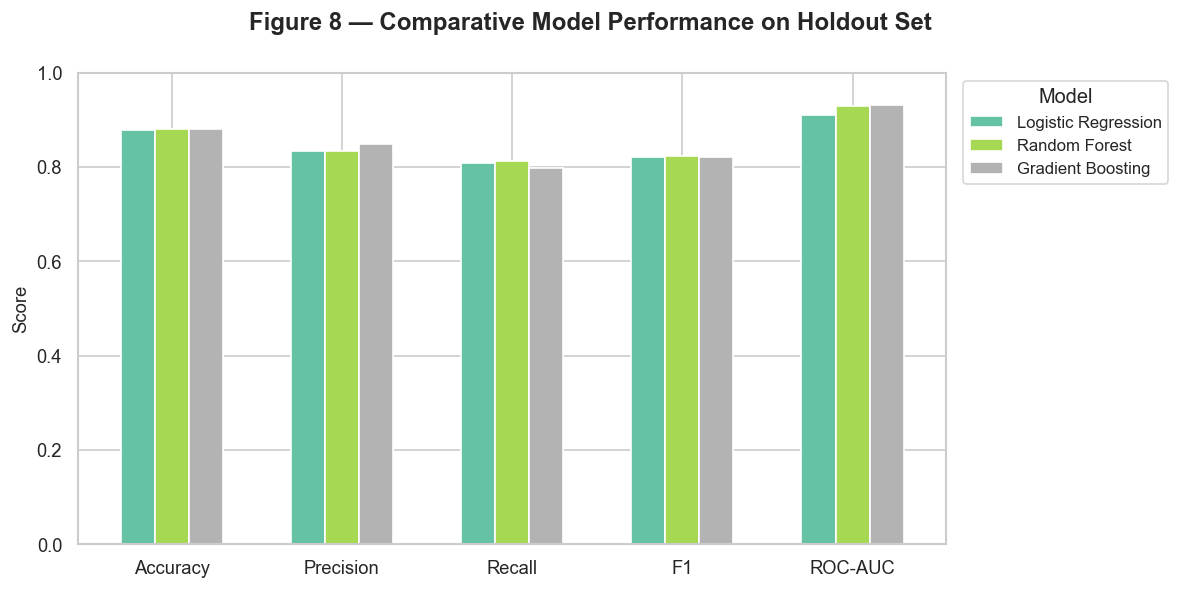

  ✓ Figure 8 displayed


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("STEP 9 — Generating Visualizations")
print("=" * 72)

# ── Figure 1: PCA Scree Plot ──────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(12, 4))
fig1.suptitle("Figure 1 — Full-Predictor PCA Scree Plot", fontweight="bold")

comp_nums = range(1, pca_full.n_components_ + 1)
axes[0].bar(comp_nums, pca_full.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("% Variance Explained")
axes[0].set_title("Individual Variance Explained")

cumvar_pct = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(comp_nums, cumvar_pct, "o-", color="darkorange", linewidth=2)
axes[1].axhline(80, ls="--", color="red", label="80% threshold")
axes[1].axvline(n_components_80, ls=":", color="green", label=f"d={n_components_80}")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative % Variance Explained")
axes[1].set_title("Cumulative Variance Explained")
axes[1].legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 1 displayed")

# ── Figure 2: K-Means Elbow & Silhouette ─────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle("Figure 2 — K-Means Elbow & Silhouette Analysis", fontweight="bold")

k_list = list(K_RANGE)
axes[0].plot(k_list, wcss, "o-", color="steelblue", linewidth=2, markersize=7)
axes[0].set_xlabel("Number of Clusters K")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(k_list, sil_scores, "s-", color="coral", linewidth=2, markersize=7)
axes[1].axvline(K_OPT, ls="--", color="green", label=f"Optimal K={K_OPT}")
axes[1].set_xlabel("Number of Clusters K")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
axes[1].legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 2 displayed")

# ── Figure 3: PCA Biplot Coloured by Cluster ─────────────────────────────────
fig3, ax = plt.subplots(figsize=(9, 6))
fig3.suptitle("Figure 3 — PCA Biplot Coloured by K-Means Cluster",
              fontweight="bold")

sample_idx = np.random.choice(N, min(3000, N), replace=False)
scatter = ax.scatter(
    Z[sample_idx, 0], Z[sample_idx, 1],
    c=cluster_labels[sample_idx], cmap="tab10",
    alpha=0.5, s=15, linewidths=0
)
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           c=range(K_OPT), cmap="tab10", marker="*",
           s=250, edgecolors="black", linewidths=1.2, label="Centroids", zorder=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PC1 vs PC2  |  K={K_OPT}  |  n={min(3000, N):,} sampled")
plt.colorbar(scatter, ax=ax, label="Cluster")
ax.legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 3 displayed")

# ── Figure 4: Cluster Profile Heatmap ────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(13, 5))
fig4.suptitle("Figure 4 — Cluster Profile Heatmap (Z-Scored Feature Means)",
              fontweight="bold")

profile_z = cluster_profile[PREDICTOR_COLS].apply(
    lambda col: (col - col.mean()) / col.std(), axis=0
)
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"label": "Z-score"})
ax.set_title("Row = Cluster  |  Column = Feature  |  Values = Z-scored mean")
plt.tight_layout()
plt.show()
print("  ✓ Figure 4 displayed")

# ── Figure 5: Logistic Regression Odds Ratios ─────────────────────────────────
fig5, ax = plt.subplots(figsize=(9, 6))
fig5.suptitle("Figure 5 — Logistic Regression Odds Ratios (eᵝ)",
              fontweight="bold")

or_df  = (pd.DataFrame({"feature": FEATURE_COLS, "OR": odds_ratios})
          .sort_values("OR").reset_index(drop=True))
colors = ["#d73027" if o > 1 else "#4575b4" for o in or_df["OR"]]
ax.barh(or_df["feature"], or_df["OR"], color=colors, edgecolor="white")
ax.axvline(1.0, color="black", linewidth=1.2, linestyle="--", label="OR=1 (no effect)")
ax.set_xlabel("Odds Ratio (eᵝ)")
ax.set_title("Red = increased odds of telemedicine use  |  Blue = decreased odds")
ax.legend()
plt.tight_layout()
plt.show()
print("  ✓ Figure 5 displayed")

# ── Figure 6: Random Forest Feature Importance ────────────────────────────────
fig6, ax = plt.subplots(figsize=(9, 6))
fig6.suptitle("Figure 6 — Random Forest Feature Importance", fontweight="bold")

sns.barplot(data=importance_df.head(15), x="importance", y="feature",
            palette="Blues_r", ax=ax)
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Top 15 Features — Telemedicine Usage Prediction")
plt.tight_layout()
plt.show()
print("  ✓ Figure 6 displayed")

# ── Figure 7: ROC Curves ──────────────────────────────────────────────────────
fig7, ax = plt.subplots(figsize=(8, 6))
fig7.suptitle("Figure 7 — ROC Curves: All Three Classifiers", fontweight="bold")

for y_prob, name, color in [
    (y_prob_lr, "Logistic Regression", "steelblue"),
    (y_prob_rf, "Random Forest",       "darkorange"),
    (y_prob_gb, "Gradient Boosting",   "green"),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — Telemedicine Usage")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
print("  ✓ Figure 7 displayed")

# ── Figure 8: Comparative Metric Bar Chart ────────────────────────────────────
fig8, ax = plt.subplots(figsize=(10, 5))
fig8.suptitle("Figure 8 — Comparative Model Performance on Holdout Set",
              fontweight="bold")

results_df.T.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.6)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("  ✓ Figure 8 displayed")

In [45]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 72)
print("FINAL SUMMARY")
print("=" * 72)

print(f"""
  Dataset           : {N:,} respondents with valid telemedicine response
  Target variable   : c17_f — Video-call / telemedicine consultation (Yes/No)
  DRS               : {pc1_variance*100:.1f}% variance in PC1 of digital readiness indicators
  Full PCA          : d = {n_components_80} components retained (>= 80% cumulative)
  Optimal K         : {K_OPT} clusters  (silhouette = {max(sil_scores):.4f})
  Feature dimension : p = {X.shape[1]}  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : {X_train.shape[0]:,} / {X_test.shape[0]:,}  (80/20, stratified)
""")

best_model = results_df["ROC-AUC"].idxmax()
print(f"  {'Model':<26}  {'Accuracy':>8}  {'Precision':>9}  "
      f"{'Recall':>6}  {'F1':>6}  {'ROC-AUC':>8}")
print("  " + "-" * 66)
for name, row in results_df.iterrows():
    marker = "  <- BEST" if name == best_model else ""
    print(f"  {name:<26}  {row['Accuracy']:>8.4f}  {row['Precision']:>9.4f}  "
          f"{row['Recall']:>6.4f}  {row['F1']:>6.4f}  {row['ROC-AUC']:>8.4f}{marker}")

lr_auc   = results_df.loc["Logistic Regression", "ROC-AUC"]
best_auc = results_df["ROC-AUC"].max()
delta    = best_auc - lr_auc
conclusion = (
    "Non-linear interactions are significant; RF/GB preferred."
    if delta > 0.03
    else "LR is competitive; parametric model is adequate and preferred for interpretability."
)
print(f"\n  AUC gap (best vs LR) = {delta:.4f}  ->  {conclusion}")
print("\n" + "=" * 72)


FINAL SUMMARY

  Dataset           : 30,629 respondents with valid telemedicine response
  Target variable   : c17_f — Video-call / telemedicine consultation (Yes/No)
  DRS               : 54.5% variance in PC1 of digital readiness indicators
  Full PCA          : d = 8 components retained (>= 80% cumulative)
  Optimal K         : 3 clusters  (silhouette = 0.2969)
  Feature dimension : p = 17  (predictors + DRS + interactions + cluster dummies)
  Train / Test      : 24,503 / 6,126  (80/20, stratified)

  Model                       Accuracy  Precision  Recall      F1   ROC-AUC
  ------------------------------------------------------------------
  Logistic Regression           0.8779     0.8334  0.8082  0.8206    0.9114
  Random Forest                 0.8800     0.8348  0.8139  0.8242    0.9306
  Gradient Boosting             0.8810     0.8491  0.7974  0.8224    0.9309  <- BEST

  AUC gap (best vs LR) = 0.0195  ->  LR is competitive; parametric model is adequate and preferred for inter

## Results Interpretation & Conclusions

### What We Studied

We analyzed the **Citizen Survey 2022-23** dataset to model telemedicine readiness in India using the pipeline from the proposal (preprocessing -> DRS feature engineering -> PCA -> clustering -> classification).

The target variable is based on `c17_f` (video-call consultations) and was recoded as follows:

- `Great Extent` or `Somewhat` -> 1 (telemedicine usage)
- `Very Little` -> 0 (non-usage)
- `DK` and `DNA` -> missing for target modeling

---

### Data and Target After Preprocessing

- Raw data: **50,217 respondents**, **232 variables**
- Rows with valid target after recoding: **30,629**
- Target distribution in analytic sample:
  - `Y=1`: **10,585** (34.6%)
  - `Y=0`: **20,044** (65.4%)
- Missing values after imputation: **0**

---

### Variable Mapping (Dataset -> Proposal)

| Proposal Variable | Dataset Variable | Final Modeling Form |
|---|---|---|
| **Target Y** | `c17_f` | Binary (1 = Great Extent/Somewhat, 0 = Very Little) |
| Age | `a2b_age` | Continuous |
| Monthly income proxy | `a2g_food` | Continuous |
| Education | `rec_a2d` -> `education` | Ordinal (1-4) |
| Gender | `a2c` -> `gender` | Binary (Female=1, Male=0) |
| Residential type | `residence` -> `rural` | Binary (Rural=1, Urban=0) |
| Internet access proxy | `c16_g` | Binary |
| Digital health behaviours | `c17_a`-`c17_e` | Binary recodes |
| Health card importance | `c18_a` | Binary |
| Digital Readiness Score | PCA over `c16_g`, `c17_a`-`c17_e` | Continuous engineered feature |

---

### Key Empirical Results

#### 1. Digital Readiness Score (DRS)

PCA on the six digital indicators produced:

- PC variance shares: **[54.5, 13.5, 12.1, 7.6, 6.9, 5.3]%**
- PC1 variance explained: **54.5%**

Since PC1 < 60%, DRS was computed using the **variance-weighted composite** (as specified in the proposal).

Largest PC1 loadings were:

- `c17_c`: +0.4643
- `c17_d`: +0.4598
- `c17_b`: +0.4399
- `c17_a`: +0.4388

This indicates that practical digital-health activities (finding providers, records access, e-pharmacy, and health information use) dominate readiness structure.

#### 2. Full-Predictor PCA and Clustering

- Full predictor PCA retained **d = 8** components to cross 80% cumulative variance.
- K-means selected **K = 3** (max silhouette = **0.2975**).

Cluster-level telemedicine usage means:

- **Cluster 1 (64.3%)**: 0.469 (highest-readiness segment)
- **Cluster 0 (7.2%)**: 0.377 (intermediate segment)
- **Cluster 2 (28.5%)**: 0.059 (digitally constrained segment)

#### 3. Logistic Regression Interpretability (Odds Ratios)

Strongest positive associations with telemedicine usage included:

- `c17_e`: **OR 4.2934**
- `DRS`: **OR 1.5654**
- `income_x_internet`: **OR 1.2269**
- `c17_d`: **OR 1.1969**
- `education`: **OR 1.1638**

Notable negative associations included:

- `cluster_2`: **OR 0.7082**
- `c18_a`: **OR 0.8781**
- `gender_x_rural`: **OR 0.9059**

#### 4. Model Performance Comparison (Holdout Set)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8779 | 0.8334 | 0.8082 | 0.8206 | 0.9114 |
| Random Forest | 0.8800 | 0.8348 | 0.8139 | 0.8242 | 0.9306 |
| Gradient Boosting | 0.8810 | 0.8491 | 0.7974 | 0.8224 | **0.9309** |

5-fold CV ROC-AUC (training):

- Logistic Regression: **0.9052 +- 0.0035**
- Random Forest: **0.9245 +- 0.0018**
- Gradient Boosting: **0.9253 +- 0.0014**

Bootstrap 95% CIs for holdout ROC-AUC (B=1000):

- Logistic Regression: **0.9114** [0.9033, 0.9192]
- Random Forest: **0.9306** [0.9236, 0.9369]
- Gradient Boosting: **0.9309** [0.9240, 0.9372]

---

### Final Interpretation

Gradient Boosting achieved the highest ROC-AUC (**0.9309**), but the AUC gain over Logistic Regression is **0.0195**, below the proposal threshold of 0.03 for strong non-linear advantage.

So the evidence from this run supports:

- Non-linear models perform best numerically, but only marginally better.
- Logistic Regression remains highly competitive and offers clearer policy interpretability through odds ratios.
- Digital behaviour variables and DRS are the dominant drivers of telemedicine readiness differences across the sample.

---

### References

Kalita, A., et al. (2026). *Citizen Survey Dataset, India*. Harvard Dataverse. https://doi.org/10.7910/DVN/M1DFBO

Nouri, S., Khoong, E. C., Lyles, C. R., & Karliner, L. (2020). Addressing equity in telemedicine for chronic disease management during the Covid-19 pandemic. *NEJM Catalyst*, 1(3).

Wosik, J., et al. (2020). Telehealth transformation: COVID-19 and the rise of virtual care. *JAMIA*, 27(6), 957-962.